# Evaluation
load the trained model, compute anomaly scores, and generate all result figures.

In [2]:
import sys
sys.path.append('..')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from dataset import load_traffic_data
from models  import TrafficLSTM

MAT_PATH   = '/gpfs/home/mminko/MikaelaM/traffic-anomaly-detection/data/traffic_dataset.mat'
MODEL_PATH = '/gpfs/home/mminko/MikaelaM/traffic-anomaly-detection/results/trained_model.pth'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

(X_tr, Y_tr, X_te, Y_te, y_scaler, Y_train_scaled, Y_test_scaled,
    sensor_cols, n_train, n_test, n_sensors, n_feats, adj_matrix) = load_traffic_data(MAT_PATH)

model = TrafficLSTM(input_size=n_feats, hidden_size=64, num_layers=2, dropout=0.2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE).eval()
print('Model loaded.')

Model loaded.


/tmp/ipykernel_1970205/3904658186.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


## 1. Training and Validation loss curves

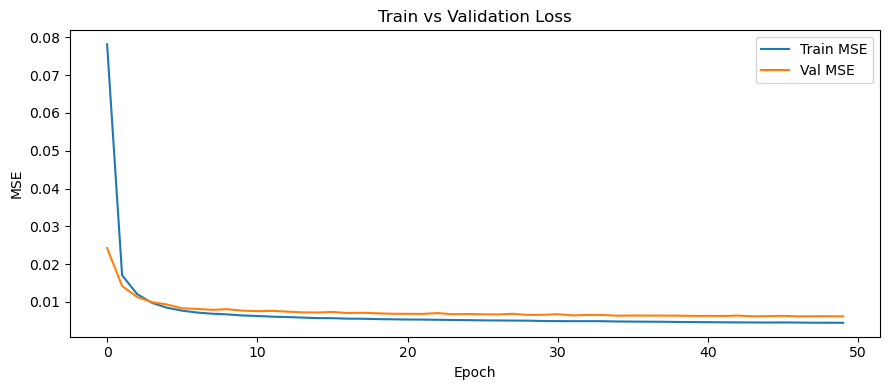

Final train MSE : 0.00447
Final val MSE   : 0.00616
Train/val ratio : 0.725


In [3]:
train_losses = np.load('/gpfs/home/mminko/MikaelaM/traffic-anomaly-detection/results/train_losses.npy')
val_losses   = np.load('/gpfs/home/mminko/MikaelaM/traffic-anomaly-detection/results/val_losses.npy')

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Train vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Final train MSE : {train_losses[-1]:.5f}')
print(f'Final val MSE   : {val_losses[-1]:.5f}')
print(f'Train/val ratio : {train_losses[-1]/val_losses[-1]:.3f}')

## 2. Overall test RMSE

In [4]:
with torch.no_grad():
    preds_te = model(X_te.to(DEVICE)).cpu().numpy()   # (N,)
    preds_tr = model(X_tr.to(DEVICE)).cpu().numpy()

actual_te = Y_te.numpy()
actual_tr = Y_tr.numpy()

overall_rmse = np.sqrt(np.mean((preds_te - actual_te)**2))
print(f'Overall test RMSE (normalised): {overall_rmse:.4f}')

Overall test RMSE (normalised): 0.0785


## 3. Predicted vs Actual - Sensor 0

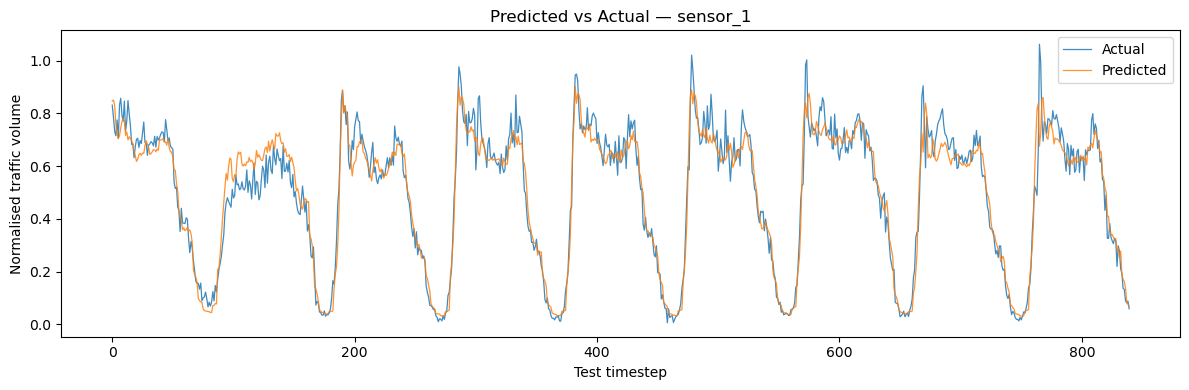

In [5]:
# Reshape to (timesteps, sensors)
actual_2d = actual_te.reshape(n_test, n_sensors)
preds_2d  = preds_te.reshape(n_test, n_sensors)

s = 0   # change to any sensor 0-35
plt.figure(figsize=(12, 4))
plt.plot(actual_2d[:, s], label='Actual',    alpha=0.85, linewidth=0.9)
plt.plot(preds_2d[:, s],  label='Predicted', alpha=0.85, linewidth=0.9)
plt.xlabel('Test timestep')
plt.ylabel('Normalised traffic volume')
plt.title(f'Predicted vs Actual — {sensor_cols[s]}')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Anomaly Detection - Set threshold from training residuals

In [10]:
train_residuals = np.abs(preds_tr - actual_tr)
threshold = np.percentile(train_residuals, 99)
print(f'Anomaly threshold (99th pct of train residuals): {threshold:.4f}')

test_residuals = np.abs(preds_te - actual_te)
anomaly_flags  = test_residuals > threshold
print(f'Flagged as anomalous: {anomaly_flags.sum():,} / {len(anomaly_flags):,}  ({100*anomaly_flags.mean():.2f}%)')

# Z-score baseline
mu, sigma = actual_te.mean(), actual_te.std()
z_flags   = np.abs(actual_te - mu) > 3 * sigma
print(f'Z-score baseline    : {z_flags.sum():,} / {len(z_flags):,}  ({100*z_flags.mean():.2f}%)')

Anomaly threshold (99th pct of train residuals): 0.2095
Flagged as anomalous: 677 / 30,240  (2.24%)
Z-score baseline    : 0 / 30,240  (0.00%)


## 5. Anomaly Heat Map

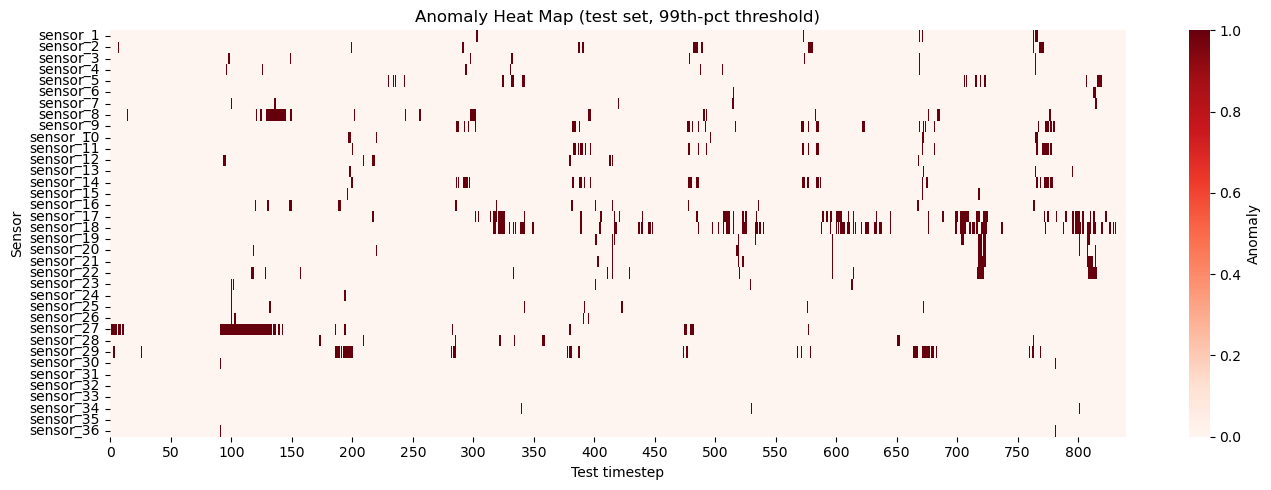

In [11]:
heat = anomaly_flags.reshape(n_test, n_sensors).astype(float)  # (timesteps, sensors)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat.T, cmap='Reds', linewidths=0,
            cbar_kws={'label': 'Anomaly'},
            xticklabels=50, yticklabels=sensor_cols, ax=ax)
ax.set_xlabel('Test timestep')
ax.set_ylabel('Sensor')
ax.set_title('Anomaly Heat Map (test set, 99th-pct threshold)')
plt.tight_layout()
plt.show()

## RMSE per Sensor

Mean RMSE  : 0.0754
Best RMSE  : 0.0460  (sensor_32)
Worst RMSE : 0.1375  (sensor_18)


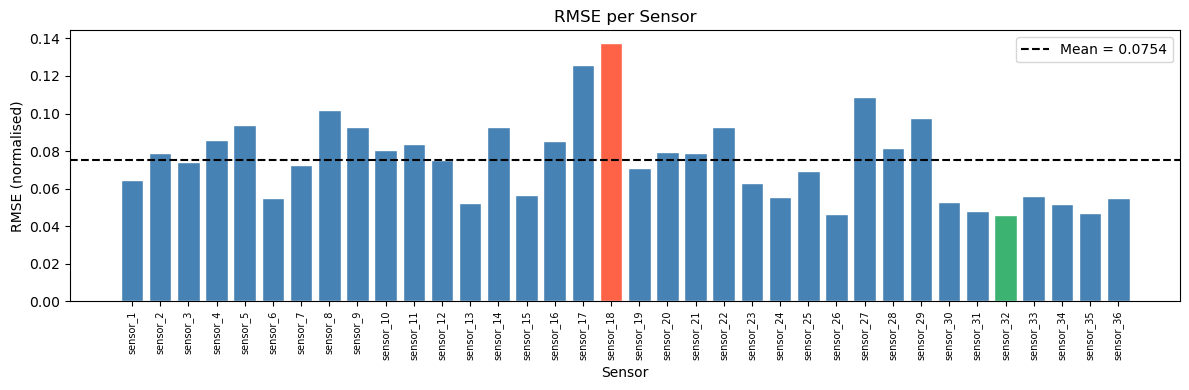

In [12]:
rmse_per_sensor = np.sqrt(np.mean((preds_2d - actual_2d)**2, axis=0))   # (36,)

print(f'Mean RMSE  : {rmse_per_sensor.mean():.4f}')
print(f'Best RMSE  : {rmse_per_sensor.min():.4f}  ({sensor_cols[rmse_per_sensor.argmin()]})')
print(f'Worst RMSE : {rmse_per_sensor.max():.4f}  ({sensor_cols[rmse_per_sensor.argmax()]})')

plt.figure(figsize=(12, 4))
colors = ['tomato' if r == rmse_per_sensor.max() else
          'mediumseagreen' if r == rmse_per_sensor.min() else
          'steelblue' for r in rmse_per_sensor]
plt.bar(sensor_cols, rmse_per_sensor, color=colors, edgecolor='white')
plt.axhline(rmse_per_sensor.mean(), color='black', linestyle='--',
            label=f'Mean = {rmse_per_sensor.mean():.4f}')
plt.xticks(rotation=90, fontsize=7)
plt.xlabel('Sensor')
plt.ylabel('RMSE (normalised)')
plt.title('RMSE per Sensor')
plt.legend()
plt.tight_layout()
plt.show()